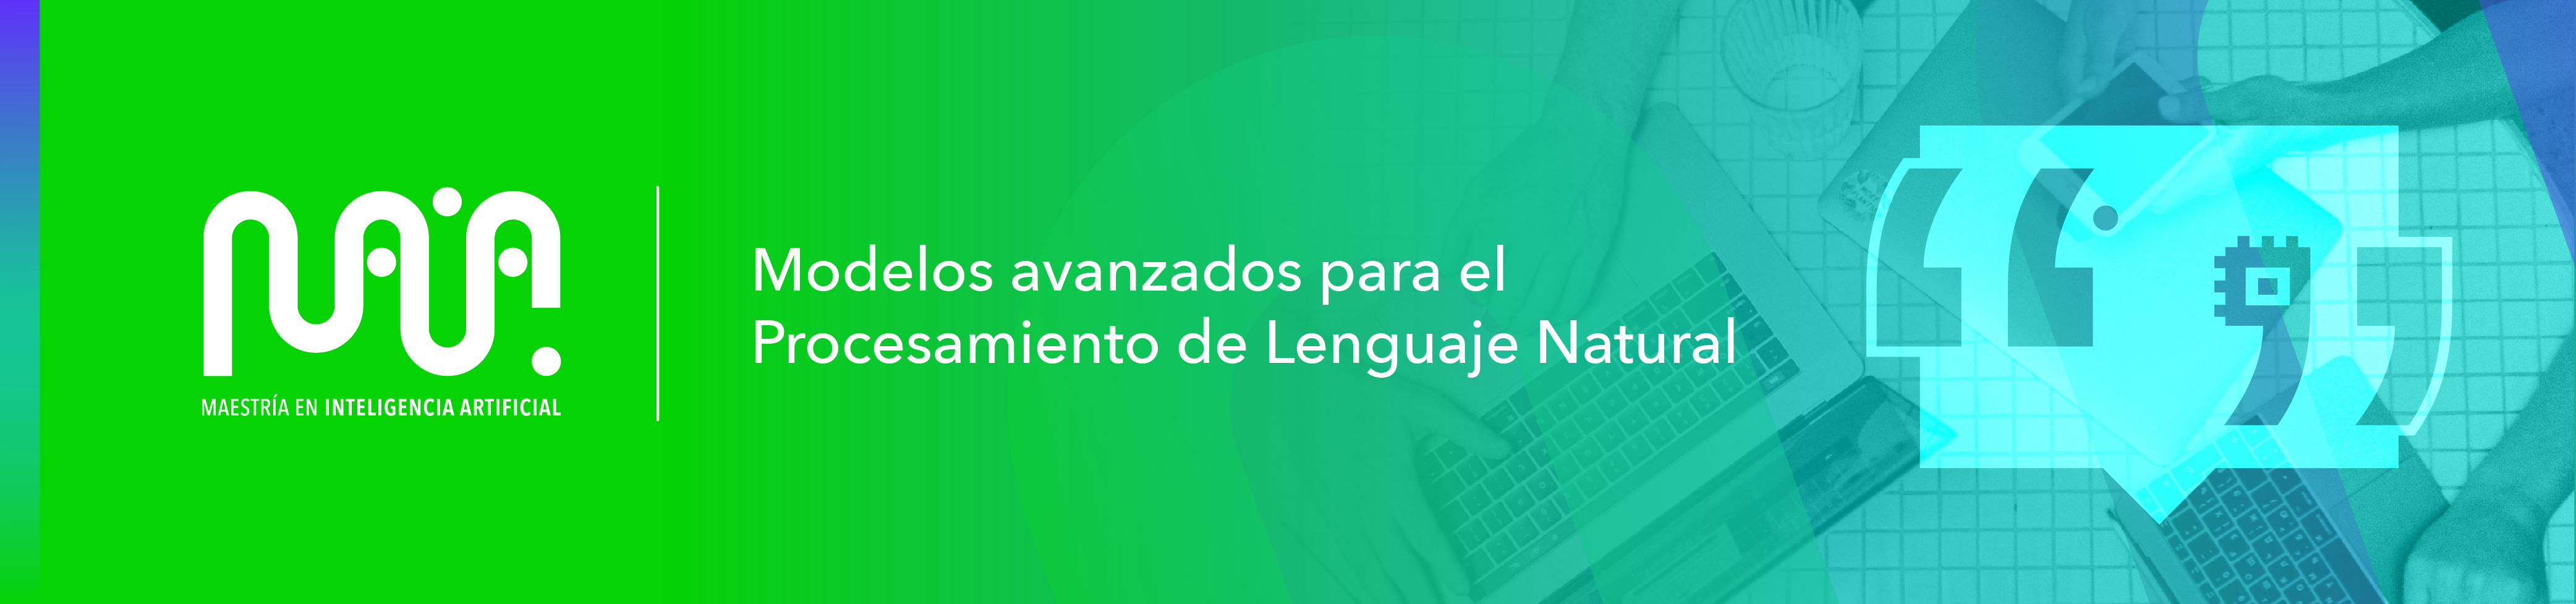

# Tutorial: Arquitectura Encoder-Decoder

En este Jupyter Notebook se introducirá la arquitectura Encoder-Decoder, comúnmente utilizada para tareas en las que se tienen secuencias como datos de entrada, y se pretende generar secuencias como salida del modelo. En este tutorial, utilizaremos redes recurrentes para demostrar cómo se pueden implementar modelos de este tipo para tareas de traducción.

**Los objetivos de aprendizaje son:**

1. Implementar un modelo Encoder-Decoder para problemas secuencia-secuencia.
2. Aprender a procesar los datos para una tarea de traducción.
3. Introducir la librería **sentencepiece** para tokenizar texto.
4. Generar traducciones mediante el modelo entrenado.

## Metodología

El tutorial utiliza un dataset con ejemplos de fragmentos de texto alineados en alemán y español, los cuales utilizaremos para implementar una arquitectura Encoder-Decoder con redes neuronales recurrentes capaz de generar traducciones. La estructura de este notebook es la siguiente:

* 1. Exploración del dataset
* 2. Tokenización del texto
* 3. Preparación de los datos para entrenamiento
* 4. Implementación del modelo
* 5. Modelo en inferencia
* 6. Conclusiones

## Importación de librerías, y definición de constantes

In [1]:
import os
os.getcwd()

'/content'

In [9]:
from google.colab import drive
drive.mount('/content/drive')
os.chdir("/content/drive/MyDrive/Andes/202612/NLP2/Tutorial3")
! dir

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
english-german	tutorial_encoder_decoder.ipynb


In [10]:
import sentencepiece as spm
import io
import csv
import os
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import math
import time

DATA_DIR = 'english-german'
TRAIN_DATA = 'wmt14_translate_de-en_train.csv'
TRAIN_DATA = 'wmt14_translate_de-en_train.csv'
VAL_DATA = 'wmt14_translate_de-en_validation.csv'

EN_TOKENIZER = 'en_tokenizer.model'
DE_TOKENIZER = 'de_tokenizer.model'

seed = 146
torch.manual_seed(seed)
np.random.seed(seed)

## 1. Exploración del dataset

Como dataset vamos a utilizar secuencias de texto alineadas de los lenguajes alemán e inglés. El dataset de entrenamiento contiene 4.5 millones de ejemplos, y puede descargarse directamente desde Kaggle: https://www.kaggle.com/datasets/mohamedlotfy50/wmt-2014-english-german. Sin embargo, para el tutorial cargaremos una carpeta comprimida con el dataset.

Como primer paso vamos a descomprimir la carpeta con el dataset:

In [11]:
!unrar x {DATA_DIR}.rar


UNRAR 6.11 beta 1 freeware      Copyright (c) 1993-2022 Alexander Roshal

Cannot open english-german.rar
No such file or directory
No files to extract


Ahora veamos el contenido de el archivo con los ejemplos de entrenamiento. Podemos observar que cada línea del archivo contiene un texto en alemán, seguido por su traducción en inglés.

In [12]:
filepath = os.path.join(DATA_DIR, TRAIN_DATA)

i = 0
with open(filepath) as csvfile:
    reader = csv.reader(csvfile)
    for row in reader:
        print(row)
        if i > 5:
            break
        i += 1

['de', 'en']
['An der B 211 befindet sich in Loyermoor der so genannte „Geest-Abbruch“, der eine Höhendifferenz von gut 30 Meter überbrückt.', 'Here the largest town of the district is located: Nordenham , lying opposite to Bremerhaven at the Weser mouth.']
['Ich begrüße die Erklärung des Herrn Kommissar und die Arbeit des Parlaments, die wirklich deutlich macht, welch konkretes Interesse wir an diesen Fragen haben, gerade unter den derzeitigen Umständen.', "I should like, in passing, to pay tribute to the Commissioner' s statement and to all the work that Parliament has carried out, which shows that we attach real importance to these issues, particularly in the current circumstances."]
['Das ist das Gegenteil von dem, was getan werden müsste, und trotzdem machen Sie so weiter.', 'That is the opposite of what should be done and yet it is what you continue to do.']
['.', '.']
['The Ethnographical museum in Varna is in a house built about 1860 as well as in an annex which is harmoniously

## 2. Tokenización del texto

En este tutorial, vamos a utilizar la librería de Google [sentencepiece](https://github.com/google/sentencepiece) para realizar una tokenización por subpalabras.

En este caso, como queremos resolver la tarea de traducción de alemán a inglés, vamos a entrenar un tokenizador por cada lenguaje con un tamaño de vocabulario de 4.096.

**Nota**: La ejecución de la siguiente celda toma aproximadamente 3 minutos en Google Colab.

In [13]:
VOCAB_SIZE = 4096

# Vamos a utilizar nuestros datos de entrenamiento para entrenar los tokenizadores
with open(filepath) as csvfile:
    # Por medio de map podemos crear un objeto iterable que solo aplica la función que se pasó como argumento
    # al momento de requerir el elemento
    phrases = map(tuple, csv.reader(csvfile, delimiter=",", ))

    # Vamos a crear una función auxiliar para crear un generador de ejemplos
    # para cada uno de los lenguajes. Este generador genera un máximo de 100.000 ejemplos.
    def text_generator(language):
        i = 0
        max_examples = 100000
        first_line = True

        # Iteración sobre el dataset
        for translation in phrases:
            # Ignorar la primera línea del csv
            if first_line:
                first_line = False
                continue

            # Algunos ejemplos pueden estar incompletos (puede faltar la traducción)
            try:
                de, en = translation
            except:
                continue

            if language == 'de':
                yield de
            else:
                yield en

            # Generar un máximo de 100.000 ejemplos
            i += 1
            if i >= max_examples:
                break

    # Crear los generadores para entrenar los tokenizadores
    de_generator = text_generator('de')
    en_generator = text_generator('en')

    # Entrenar el tokenizador de alemán
    model_de = io.BytesIO()
    spm.SentencePieceTrainer.train(
      sentence_iterator=de_generator, model_writer=model_de, vocab_size=VOCAB_SIZE, pad_id=0, unk_id=1, bos_id=2, eos_id=3, byte_fallback=True)
    sp_de = spm.SentencePieceProcessor(model_proto=model_de.getvalue())

    # Entrenar el tokenizador de inglés
    model_en = io.BytesIO()
    spm.SentencePieceTrainer.train(
      sentence_iterator=en_generator, model_writer=model_en, vocab_size=VOCAB_SIZE, pad_id=0, unk_id=1, bos_id=2, eos_id=3, byte_fallback=True)
    sp_en = spm.SentencePieceProcessor(model_proto=model_en.getvalue())

Luego de entrenar los tokenizadores, podemos guardarlos en el disco.

In [14]:
with open(DE_TOKENIZER, 'wb') as f:
  f.write(model_de.getvalue())

with open(EN_TOKENIZER, 'wb') as f:
  f.write(model_en.getvalue())

Tokenizadores guardados en el disco, pueden cargarse de la siguiente manera:

In [15]:
sp_de = spm.SentencePieceProcessor()
sp_de.load(DE_TOKENIZER)

sp_en = spm.SentencePieceProcessor()
sp_en.load(EN_TOKENIZER)

True

Los tokenizadores de **sentencepiece** pueden usarse fácilmente para tokenizar y codificar el texto, de manera que podamos usarlo en el entrenamiento de modelos de machine learning.

In [16]:
encoded = sp_en.encode('this is a test')
encoded

[285, 270, 268, 1175]

La forma en la que se entrenan los tokenizadores en **sentencepiece** permiten tokenizar texto con caracteres nunca observados durante su entrenamiento. Sin embargo, este comportamiento debe especificarse durante el entrenamiento del tokenizador mediante el argumento **byte_fallback** (el cual agregamos).

In [17]:
# Prueba en español
encoded = sp_en.encode('Esto es una prueba en español')
print(encoded)

# Prueba con emojis
encoded = sp_en.encode('😀')
print(encoded)

[394, 261, 469, 443, 261, 434, 307, 1406, 1312, 850, 677, 443, 261, 901, 199, 181, 429]
[269, 244, 163, 156, 132]


Adicionalmente, el tokenizador nos permite ver la tokenización a nivel de tokens antes de la codificación a ids.

In [18]:
sp_en.encode('this is a test', out_type=str)

['▁this', '▁is', '▁a', '▁test']

Por otro lado, podemos decodificar una secuencia de ids de vuelta a texto.

In [19]:
encoded = sp_en.encode('Esto es una prueba en español')

decoded = sp_en.decode(encoded)
decoded

'Esto es una prueba en español'

Finalmente, usemos los tokenizadores entrenados para tokenizar nuestros datos de entrenamiento. Para el caso de las secuencias de texto en inglés (traducción) vamos a agregar el token especial que representa el inicio de la secuencia al comienzo, y vamos a usar el token de fin de secuencia para agregarlo al final de la traducción.

In [20]:
def tokenize(text, translation):
    return sp_de.encode(text), [sp_en.bos_id()] + sp_en.encode(translation) + [sp_en.eos_id()]

# Guardamos en listas las secuencias tokenizadas y codificadas
train_data_text = []
train_data_translation = []

# Vamos a utilizar únicamente los 100 mil primeros ejemplos como nuestros datos de entrenamiento
with open(filepath) as csvfile:
    phrases = map(tuple, csv.reader(csvfile, delimiter=",", ))
    i = 0
    max_lines = 100000
    first_line = True
    for translation in phrases:
        if first_line:
            first_line = False
            continue
        try:
            de, en = translation
        except:
            continue
        # Se tokenizan y codifican la secuencias
        de, en = tokenize(de, en)

        # Únicamente vamos a tomar secuencias con un máximo de 64 tokens
        if len(de) > 64 or len(en) > 64:
            continue

        # Guardamos las secuencias tokenizadas y tokenizadas
        train_data_text.append(de)
        train_data_translation.append(en)

        i += 1
        if i >= max_lines:
            break

# Como secuencias de validación tomaremos un máximo de 10 mil ejemplos
valfile = os.path.join(DATA_DIR, VAL_DATA)
val_data_text = []
val_data_translation = []
with open(valfile) as csvfile:
    phrases = map(tuple, csv.reader(csvfile, delimiter=",", ))
    i = 0
    max_lines = 10000
    first_line = True
    for translation in phrases:
        if first_line:
            first_line = False
            continue
        try:
            de, en = translation
        except:
            continue

        if len(de) > 64 or len(en) > 64:
            continue
        de, en = tokenize(de, en)
        val_data_text.append(de)
        val_data_translation.append(en)
        i += 1

        if i >= max_lines:
            break

Revisemos el número de ejemplos de entrenamiento y validación obtenidos:

In [21]:
len(train_data_text), len(val_data_text)

(100000, 599)

## 3. Preparación de los datos para el entrenamiento del modelo de traducción

Implementemos una clase para recorrer los ejemplos del dataset de una forma que sea conveniente para el modelo de traducción que vamos a construir. Para ello, pensemos en los requerimientos del modelo:

* Necesitamos identificar claramente que tokens pertenecen a alemán, y cuáles a inglés. Esto es necesario porque tenemos dos tokenizadores diferentes, y por lo tanto dos vocabularios diferentes que no podemos mezclar.
* Necesitamos crear las etiquetas de nuestro modelo, en donde, para una secuencia de texto (incluyendo texto en alemán) tendremos como etiqueta el siguiente token en inglés.

Como se puede observar en la figura, de manera similar a como lo vimos con los modelos de lenguaje, para un mismo ejemplo el modelo debe aprender a generar todos los tokens siguientes. Con la diferencia, de que el modelo siempre recibirá una secuencia completa en alemán más el token especial (`<s>`) y solo se evaluará su capacidad de generar los tokens en inglés.

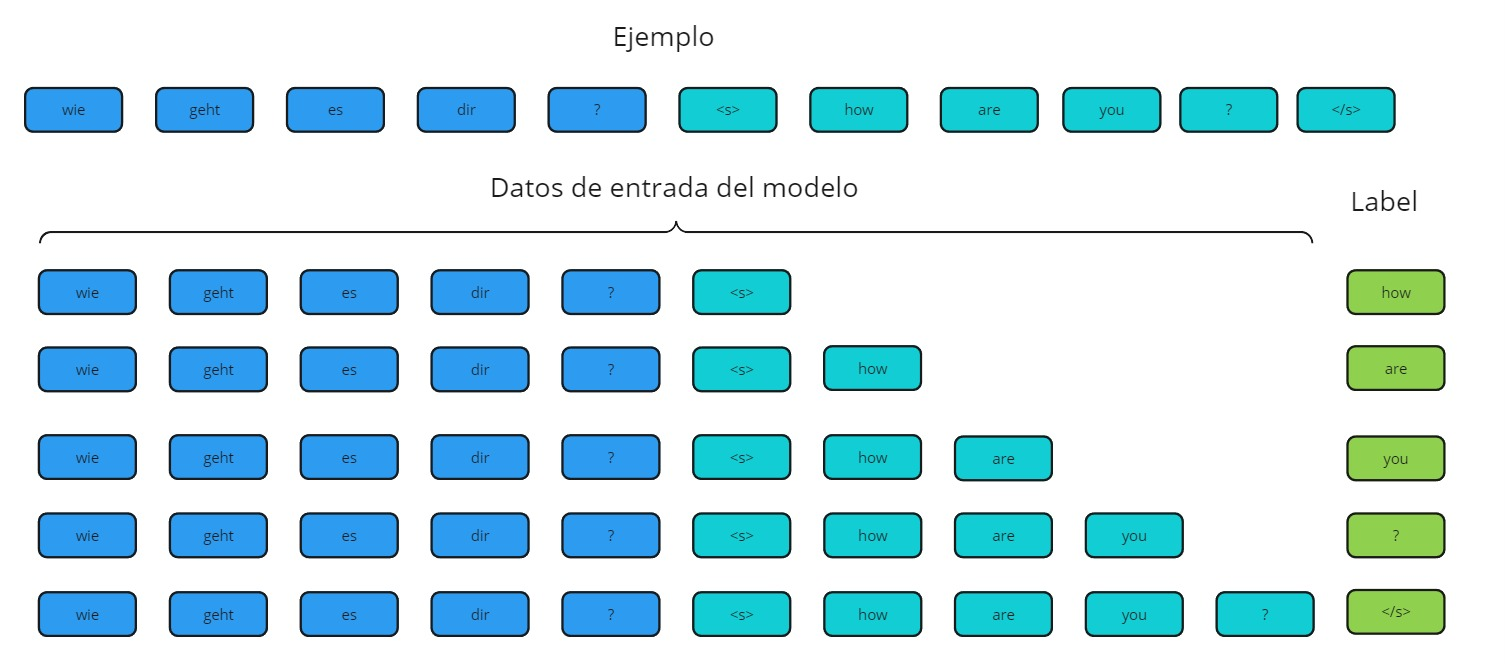

Implementemos la clase `DataLoader` en donde vamos a recorrer los ejemplos del dataset en un orden aleatorio. Adicionalmente, implementaremos el método `get_batch` para obtener los ejemplos de entrenamiento, que consistirán en los datos de entrada (secuencia en alemán, y secuencia parcial en inglés por separado), y la etiqueta (token siguiente en inglés).

In [22]:
class DataLoader:
    def __init__(self, texts, translations, minimum_batch_size=5) -> None:
        self.texts = texts # Secuencias de texto tokenizadas y codificadas en alemán
        self.translations = translations # Secuencias de texto tokenizadas y codificadas en inglés
        self.order = np.random.permutation(len(self.texts)) # Orden inicial en que se van a recorrer los ejemplos
        self.curr_pos = 0 # Posición actual sobre el dataset
        self.minimum_batch_size = minimum_batch_size # Tamaño mínimo de lote

    def get_batch(self, batch_size):
        end_pos = self.curr_pos + batch_size
        ids = self.order[self.curr_pos:end_pos] # Índices de los ejemplos que van a hacer parte del lote
        self.curr_pos = end_pos # Actualizar posición en el dataset

        # Cuando se recorra completamente el dataset, crear un nuevo orden para recorrerlo
        if self.curr_pos > len(self.order) - 1:
            self.curr_pos = 0 # Reiniciar la posición en el dataset
            self.order = np.random.permutation(len(self.texts))

        # Si no se cumple el tamaño mínimo del lote, tomar el lote nuevamente
        if len(ids) < batch_size and len(ids) < self.minimum_batch_size:
            return self.get_batch(batch_size)

        # Tomar las secuencias de texto del lote
        texts = [self.texts[i] for i in ids]
        translations = [self.translations[i] for i in ids]

        # Para hacer el entrenamiento del modelo más eficiente, todas las secuencias del lote deben tener un
        # mismo tamaño. Este permite que todo el lote se pueda pasar en un único forward pass del modelo
        text_max_length = len(max(texts, key=lambda x: len(x))) # Tamaño máximo de las secuencias en alemán
        translation_max_length = len(max(translations, key=lambda x: len(x))) # Tamaño máximo de las secuencias en inglés
        # Padding de las secuencias
        # A las secuencias en alemán se les hace padding hacia la izquierda
        texts = np.array([np.pad(item, pad_width=(text_max_length-len(item),0), constant_values=sp_de.pad_id()) for item in texts])
        # A las secuencias en inglés se les hace padding hacia la derecha
        _translations = np.array([np.pad(item, pad_width=(0, translation_max_length-len(item)), constant_values=sp_en.pad_id()) for item in translations])

        texts = torch.tensor(texts).int()
        translations = torch.tensor(_translations[:,:-1]).int()
        # Se crean las etiquetas que corresponden al token siguiente en inglés
        labels = torch.tensor(_translations[:,1:])

        return texts, translations, labels


In [23]:
train_dataloader = DataLoader(train_data_text, train_data_translation)

Veamos 3 ejemplos de entrenamiento:

In [24]:
texts, translations, labels = train_dataloader.get_batch(3)

In [25]:
texts.shape, translations.shape, labels.shape

(torch.Size([3, 41]), torch.Size([3, 62]), torch.Size([3, 62]))

Note como las secuencias en alemán e inglés pueden llegar a tener distintos tamaños.

Veamos también la forma en el que modelo verá los ejemplos de entrenamiento:

In [26]:
# Ver ejemplos de entrenamiento
for i in range(len(texts)):
    print(f'Ejemplo {i+1}')

    for context_length in range(len(translations[i])):
        # Texto a traducir
        de_text = sp_de.decode(texts[i].tolist())
        # Contexto parcial en inglés
        partial_en_text = sp_en.decode(translations[i][:context_length+1].tolist())
        # Etiqueta que debe generar el modelo
        target = sp_en.id_to_piece(labels[i][context_length].item())
        print(f'{de_text} | {partial_en_text} -> {target}')
        print('')
    print('--------------------------')

Ejemplo 1
Bei der Biennale in Venedig gab es in diesem Jahr zum ersten Mal einen Pavillon, in dem Kunst von in mehreren europäischen Ländern lebenden Roma ausgestellt wurde. |  -> ▁This

Bei der Biennale in Venedig gab es in diesem Jahr zum ersten Mal einen Pavillon, in dem Kunst von in mehreren europäischen Ländern lebenden Roma ausgestellt wurde. | This -> ▁year

Bei der Biennale in Venedig gab es in diesem Jahr zum ersten Mal einen Pavillon, in dem Kunst von in mehreren europäischen Ländern lebenden Roma ausgestellt wurde. | This year -> ▁the

Bei der Biennale in Venedig gab es in diesem Jahr zum ersten Mal einen Pavillon, in dem Kunst von in mehreren europäischen Ländern lebenden Roma ausgestellt wurde. | This year the -> ▁V

Bei der Biennale in Venedig gab es in diesem Jahr zum ersten Mal einen Pavillon, in dem Kunst von in mehreren europäischen Ländern lebenden Roma ausgestellt wurde. | This year the V -> en

Bei der Biennale in Venedig gab es in diesem Jahr zum ersten Mal einen 

Observe como por cada ejemplo el modelo debe aprender a generar todos los tokens en inglés.

Las secuencias en inglés de los ejemplos varían en longitud, por lo que en algunos ejemplos se agregó el token `<pad>`. Sin embargo, no queremos que el modelo aprenda a predecir estos tokens, por lo que debemos ignorarlos durante el entrenamiento.

**Nota**: Tenga en cuenta que el método `decode` omite algunos tokens. Por ejemplo, no se muestra el token `<s>` al inicio de la secuencia en inglés ni el token `</s>` al final de la secuencia, así como tampoco los tokens de padding `<pad>` presentes tanto a la izquierda de algunas secuencias en alemán, y a la derecha de algunas secuencias en inglés. Por el contrario, en la etiqueta sí se muestran estos tokens porque se usó el método `id_to_piece`.

In [27]:
# Observemos de nuevo el segundo ejemplo del lote

# Texto en alemán
print([sp_de.id_to_piece(piece.item()) for piece in texts[1]])
# Texto en inglés
print([sp_en.id_to_piece(piece.item()) for piece in translations[1]])

['<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '▁Leider', '▁werden', '▁diese', '▁Regelung', 'en', '▁den', '▁Verbraucher', 'n', '▁nur', '▁vor', 'der', 'g', 'rü', 'ndig', '▁zu', 'gu', 'te', '▁kommen', '.']
['<s>', '▁Unfortunately', '▁these', '▁regulations', '▁will', '▁only', '▁super', 'fici', 'ally', '▁benefit', '▁consumers', '.', '</s>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>']


## Implementación del modelo

Para la tarea de traducción se va a implementar una arquitectura encoder-decoder como se presenta en la figura a continuación.

Este modelo consiste en un encoder, que usa una secuencia de capas LSTM bidireccionales para recoger toda la información importante sobre el texto en alemán. Esta información se almacena en **h_e**, y se calcula como el promedio de los estados ocultos finales de la última capa de LSTM bidireccional. Por otro lado, el decoder consiste en una secuencia de capas LSTM (no bidireccionales) que reciben como input no solo el embedding del token, y el estado oculto anterior, sino también a **h_e**, el cual se concatena junto con el embedding del token para generar la traducción.

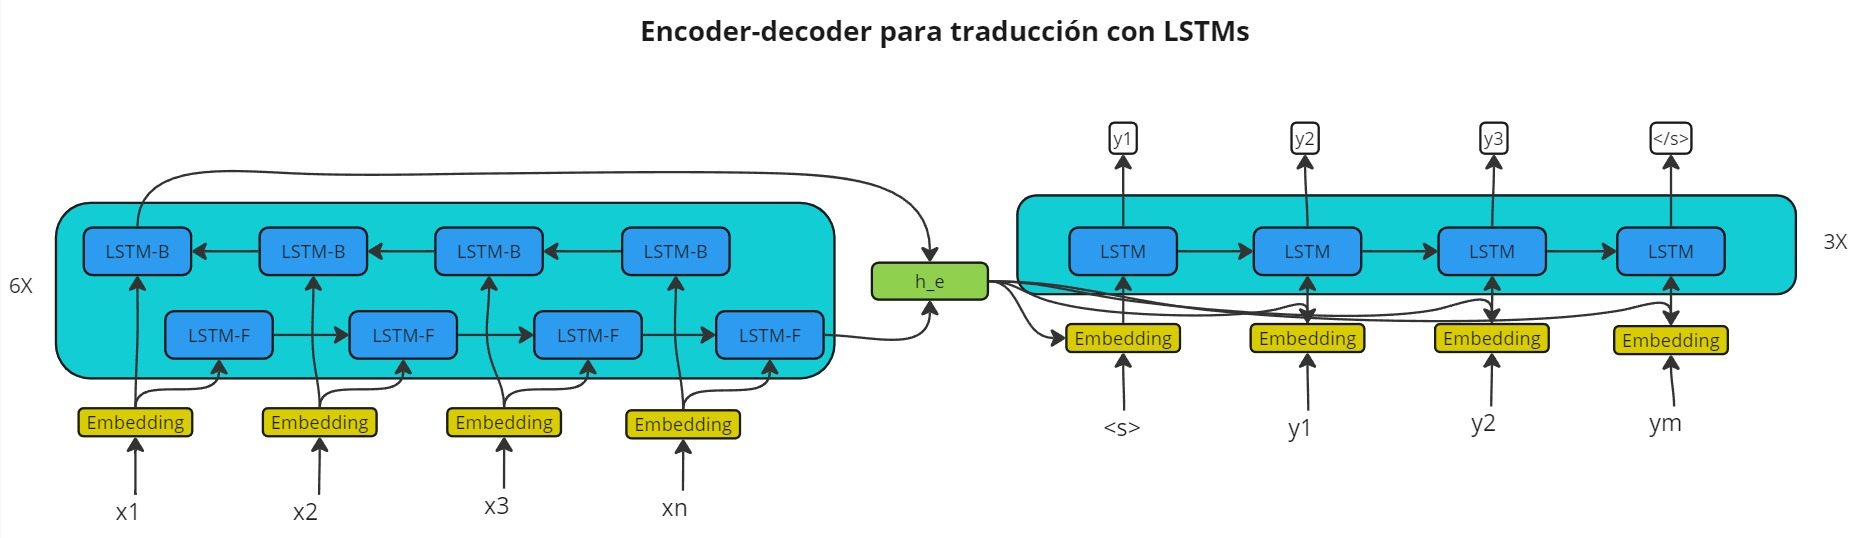

In [28]:
vocab_size = sp_en.vocab_size()
embed_dim = 128 # Tamaño de los embeddings de los tokens
h_size_encoder = 256 # Tamaño del estado oculto del encoder
h_size_decoder = 512 # Tamaño del estado oculto del decoder
decoder_in = embed_dim + h_size_encoder # La entrada al decoder es la concatenación del estado oculto del encoder y el embedding del token
batch_size = 128 # Número de ejemplos que el modelo recibe al tiempo en entrenamiento

class RNNTranslator(nn.Module):
    def __init__(self) -> None:
        super().__init__()
        # Embeddings de los tokens en alemán
        # Al pasar padding_idx, La capa Embedding asigna un embedding de solo zeros al id indicado
        self.E_de = nn.Embedding(sp_de.vocab_size(), embed_dim, padding_idx=sp_de.pad_id())
        # Embeddings de los tokens en inglés
        self.E_en = nn.Embedding(sp_en.vocab_size(), embed_dim, padding_idx=sp_en.pad_id())
        # Encoder
        self.encoder = nn.LSTM(embed_dim, h_size_encoder, num_layers=6, batch_first=True, bidirectional=True)
        # Decoder
        self.decoder = nn.LSTM(decoder_in, h_size_decoder, num_layers=3, batch_first=True)
        # Cabeza de lenguaje para predecir el siguiente token en inglés
        self.final_proj = nn.Linear(h_size_decoder, vocab_size)

    def forward(self, text, translation):
        # Embeddings de los tokens en alemán
        x1 = self.E_de(text)
        # Embeddings del los tokens en inglés
        x2 = self.E_en(translation)

        # Paso por el encoder de las secuencias en alemán
        h_states, _ = self.encoder(x1)
        # Se calcula la representación de la secuencia en alemán como el promedio de los estados ocultos en las dos direcciones
        # de la capa final de LSTM bidireccional.
        # h_states contiene los estados ocultos para todas las capas, y el resultado de las dos direcciones está concatenado en la dimensión final,
        # por lo tanto h_states.shape = [ejemplos, capas (6), h_size_encoder*2]
        h_e = h_states[:,[-1],:].view(text.shape[0], 2, h_size_encoder).mean(1, keepdim=True) # [ejemplos, 1, h_size_encoder]
        # Replicamos h_e en su segunda dimensión para que cada token en inglés contenga el h_e de la secuencia en alemán
        h_e = h_e.repeat(1, translation.shape[1], 1)
        # Concatenamos el cada uno de los embeddings de los tokens en inglés con h_e
        x2 = torch.cat((x2, h_e), dim=2)

        # Realizamos el paso por el decoder
        h_states, _ = self.decoder(x2)

        # Calculamos los logits para cada token en el vocabulario de inglés
        logits = self.final_proj(h_states)
        return logits


In [29]:
model = RNNTranslator()
print(f'Parámetros del modelo: {sum([p.nelement() for p in model.parameters()]):,}')
model

Parámetros del modelo: 17,866,752


RNNTranslator(
  (E_de): Embedding(4096, 128, padding_idx=0)
  (E_en): Embedding(4096, 128, padding_idx=0)
  (encoder): LSTM(128, 256, num_layers=6, batch_first=True, bidirectional=True)
  (decoder): LSTM(384, 512, num_layers=3, batch_first=True)
  (final_proj): Linear(in_features=512, out_features=4096, bias=True)
)

## 5. Entrenamiento del modelo

En esta sección vamos a realizar el entrenamiento del modelo implementado en la sección anterior.

In [30]:
# Vamos a realizar el entrenamiento en GPU si está disponible
device = 'cuda' if torch.cuda.is_available() else 'cpu'
device

'cuda'

Vamos a crear una función auxiliar para estimar la función de costo para los datasets de entrenamiento y validación de una manera más precisa.

In [31]:
@torch.no_grad
def estimate_loss(model: torch.nn.Module, train_eval: DataLoader, val_eval: DataLoader, batch_size: int = 256, eval_iters: int = 10):
    model.eval() # Se debe informar a Pytorch que estamos en modo evaluación, esta información puede ser usada por alguna de las capas usadas como por ejemplo Dropout
    train_losses = []
    val_losses = []
    # Iteramos sobre un número de lotes definido para tener una mejor estimación del valor de pérdida en cada uno de los sets
    for i in range(eval_iters):
        x1, x2, y = train_eval.get_batch(batch_size)
        x1, x2, y = x1.to(device), x2.to(device), y.to(device) # Se envían los tensores al dispositivo en el que tenemos el modelo, ya sea CPU o GPU
        y_pred = model(x1, x2) # Se calculan los logits
        # Se calcula el valor de pérdida
        loss = torch.nn.functional.cross_entropy(y_pred.view(-1, vocab_size), y.view(-1), ignore_index=sp_en.pad_id()) # Se ignora la predicción del modelo para los tokens de padding
        train_losses.append(loss.item())

        # Se realizan los mismos pasos en el set de validación
        x1, x2, y = val_eval.get_batch(batch_size)
        x1, x2, y = x1.to(device), x2.to(device), y.to(device)
        y_pred = model(x1, x2)
        loss = torch.nn.functional.cross_entropy(y_pred.view(-1, vocab_size), y.view(-1), ignore_index=sp_en.pad_id())
        val_losses.append(loss.item())

    # Promedio del valor de pérdida sobre los lotes
    train_loss = sum(train_losses)/eval_iters
    val_loss = sum(val_losses)/eval_iters

    model.train() # Se cambia el estado del modelo nuevamente a modo entrenamiento
    return train_loss, val_loss

Definamos la función que realiza el entrenamiento del modelo.

In [32]:
# Definir la data con la que se estimará el valor de pérdida en el set de entrenamiento y validación
train_eval_dataloader = DataLoader(train_data_text, train_data_translation)
val_dataloader = DataLoader(val_data_text, val_data_translation)

# Función para definir el bucle de entrenamiento del modelo
def training_loop(model, lr, max_steps, data_loader: DataLoader, weight_decay: float = 0.0, log_steps = 10):
    train_losses = []
    val_losses = []

    model.train()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay, fused=True)

    print(f'Entrenando por {max_steps} pasos')
    prev_step = 0
    t0 = time.time()
    for step in range(max_steps):
        optimizer.zero_grad()
        x1, x2, y = data_loader.get_batch(batch_size)
        x1, x2, y = x1.to(device), x2.to(device), y.to(device)
        y_pred = model(x1, x2)
        loss = torch.nn.functional.cross_entropy(y_pred.view(-1, vocab_size), y.view(-1), ignore_index=sp_en.pad_id())

        loss.backward()
        # Evitar que los gradientes sean mayores a 1
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()

        # Logs
        if (step+1) % log_steps == 0 or step == 0 or step == max_steps-1:
            train_loss, valid_loss = estimate_loss(model, train_eval_dataloader, val_dataloader, batch_size=batch_size, eval_iters=2000//batch_size)
            t1 = time.time()
            dt = (t1 - t0)
            t0 = time.time()
            examples_per_sec = batch_size*(step+1-prev_step)/dt
            prev_step = step+1
            print(f'Step {step+1:4d} - Train loss: {train_loss:4.2f} - Valid loss: {valid_loss:4.2f}, exs/sec:{examples_per_sec:5.0f}')
            train_losses.append(train_loss)
            val_losses.append(valid_loss)

    return train_losses, val_losses

In [33]:
batches_per_epoch = math.ceil(len(train_data_text) / batch_size)
batches_per_epoch

782

Entrenemos el modelo por 3 épocas.

**Nota**: La ejecución de la siguiente celda tarda aproximadamente 11 minutos en Google Colab con GPU activa.

In [34]:
%%time
model = RNNTranslator()
model.to(device)
# Compilar el modelo puede ayudar a aumentar la velocidad del entrenamiento
# model = torch.compile(model)
train_losses, val_losses = training_loop(model, 0.01, 3*batches_per_epoch, train_dataloader, log_steps=350)

Entrenando por 2346 pasos
Step    1 - Train loss: 7.43 - Valid loss: 7.43, exs/sec:   42
Step  350 - Train loss: 5.25 - Valid loss: 5.25, exs/sec:  506
Step  700 - Train loss: 4.88 - Valid loss: 4.98, exs/sec:  446
Step 1050 - Train loss: 4.62 - Valid loss: 4.84, exs/sec:  444
Step 1400 - Train loss: 4.49 - Valid loss: 4.75, exs/sec:  443
Step 1750 - Train loss: 4.40 - Valid loss: 4.66, exs/sec:  445
Step 2100 - Train loss: 4.31 - Valid loss: 4.63, exs/sec:  444
Step 2346 - Train loss: 4.29 - Valid loss: 4.61, exs/sec:  442
CPU times: user 11min 4s, sys: 1.85 s, total: 11min 6s
Wall time: 11min 13s


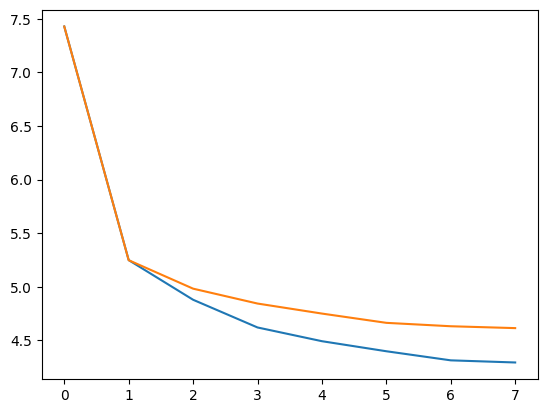

In [35]:
plt.plot(train_losses)
plt.plot(val_losses)

Debido a la alta complejidad de esta tarea se requieren modelos con cientos de millones de parámetros o incluso billones para alcanzar un buen desempeño en traducción. Adicionalmente, se entrenan los modelos con grandes cantidades de datos por largos periodos de tiempo.

## Modelo en inferencia

En esta sección vamos a ver como utilizar nuestro modelo para generar traducciones.

Primero, tomamos un ejemplo de nuestro set de entrenamiento:

In [36]:
text, translation, label = train_dataloader.get_batch(1)

Veamos el texto en alemán:

In [37]:
sp_de.decode(text[0].tolist())

'Genausogut könnte dies ein heller Fleck auf der Erdoberfläche sein.'

Traducción en inglés:

In [38]:
sp_en.decode(translation[0].tolist())

"There is no definite distinction to some bright area at the Earth's surface itself."

Vamos a crear una función para generar las traducciones, similar a la que hemos usado en generación de texto.

In [39]:
@torch.no_grad
def translate(model, text: torch.tensor, max_tokens = 200, temperature = 1, top_p = 1):
    model.eval() # Poner nuestro modelo en modo evaluación
    # La traducción debe iniciar con el token de inicio de sentencia
    translation = torch.tensor([[sp_en.bos_id()]]).to(device)
    # Bucle de generación
    for i in range(max_tokens):
        pred = model(text, translation) # Pásamos a nuestro modelo el texto en alemán y el texto parcial generado en inglés
        pred = pred[:,-1,:] # Solo tomamos la predicción realizada para el último token de la secuencia de entrada
        scaled_pred = pred / temperature # Se escalan los logits por el valor de temperatura. Note que si temperature=1 los logits permanecen igual
        probs = torch.nn.functional.softmax(scaled_pred, dim=-1) # Convertimos la salida del modelo en una distribución de probabilidad

        # Ordenar las probabilidades en orden descendiente
        sorted_probs, sorted_indices = torch.sort(probs, descending=True)
        # Calcular la probabilidad acumulada
        cumulative_probs = torch.cumsum(sorted_probs, dim=-1)
        # Determinar el punto hasta el cual se van a considerar tokens
        cutoff = cumulative_probs <= top_p
        # Normalizar las probabilidades tomando en cuenta solo los tokens que entran en el top_p
        top_p_probs = sorted_probs[cutoff]
        top_p_probs = top_p_probs/ top_p_probs.sum()

        # Si no hay tokens con probabilidad menor a top_p, utilizar la generación estándar
        if len(top_p_probs) == 0:
            probs = torch.nn.functional.softmax(scaled_pred, dim=-1)
            next_tok = torch.multinomial(probs, 1)
        else:
            next_tok = torch.multinomial(top_p_probs, 1) # Seleccionamos el siguiente token de forma aleatoria
            next_tok = (sorted_indices[0][next_tok]).unsqueeze(0)

        translation = torch.cat((translation, next_tok), dim=1) # Agregamos el nuevo token para realizar la siguiente generación

        # Se termina la generación cuando se genera el token de fin de sentencia
        if next_tok[0].item() == sp_en.eos_id():
            break

    return sp_en.decode(translation[0].cpu().tolist()) # Decodificamos los tokens

Traducción generada por el modelo:

In [40]:
x1 = text.to(device)
sample_translation = translate(model, x1, temperature=0.5, top_p=0.6)
sample_translation

'The Commission has been accused in the Committee on Budgetary Control.'

Para tareas de traducción, suelen usarse también otro tipo de técnicas para generar la traducción de los modelos como **beam search**. Esta técnica consiste en definir el tamaño del beam (B), y de acuerdo a ese tamaño guardar como posibles traducciones los B tokens más probables, y luego por cada una de las B opciones, generar de nuevo los B tokens más probables por cada una. Una vez se predice el token de fin de sentencia, se guarda la traducción completa y se elimina la opción del beam, y para evitar el crecimiento exponencial de las opciones, en cada paso únicamente permanecen en el beam las B opciones más probables.

In [41]:
@torch.no_grad
def beam_translation(model, text, max_tokens = 64, B=4):
    model.eval() # Poner nuestro modelo en modo evaluación
    beam = torch.tensor([[[sp_en.bos_id()], [1.0]]]).to(device) # [partials, 2 (tokens, probs), length]

    hypotheses = [] # Traducciones completas generadas

    # Bucle de generación
    for i in range(max_tokens):
        # Se revisa qué traducciones del beam están completas
        completed_mask = beam[:,0,-1] == sp_en.eos_id()
        new_hypotheses = sp_en.decode(beam[completed_mask][:,0].int().tolist())
        # Se guardan las traducciones que están completas
        hypotheses +=  new_hypotheses
        # Solo se mantienen en el beam las traducciones incompletas
        beam = beam[completed_mask == False]
        x1_copy = text.repeat(len(beam), 1) # Se replica el texto en alemán para realizar un paso por el modelo por cada traducción parcial

        # Se generan los logits del siguiente token, tomando únicamente los logits para el último token de la traducción parcial
        preds = model(x1_copy, beam[:,0,:].int())[:,-1,:]

        # Se convierten los logits en probabilidades
        probs = torch.nn.functional.softmax(preds, dim=-1)
        # Se ordenan los tokens de acuerdo a su probabilidad
        sorted_probs, sorted_tokens = torch.sort(probs, descending=True, dim=1)
        # Se toman los tokens junto con su probabilidad y se agregan al beam
        new_opts = torch.stack((sorted_tokens[:,:B].reshape(-1), sorted_probs[:,:B].reshape(-1)), dim=1).unsqueeze(2)
        # Por cada traducción parcial se agregan B nuevas traducciones parciales con los B tokens más probables
        beam = beam.repeat_interleave(torch.tensor(B).to(device), dim=0)
        beam = torch.cat((beam, new_opts), dim=2)

        # Para evitar el crecimiento exponencial del beam, únicamente se conservan las B traducciones parciales más probables
        opts_probs,  sorted_opts_ids = torch.sort(torch.log(beam[:,1,:]).sum(1), descending=True)
        beam = beam[sorted_opts_ids[:B]]

    # Si no se encontraron traducciones completas, se retornan las traducciones parciales
    if hypotheses == []:
        return sp_en.decode(beam[:,0].int().tolist())

    # Se retornan todas las traducciones completas encontradas
    return hypotheses

# Ejemplo de generación de traducciones con beam search
x1 = text.to(device)
results = beam_translation(model, x1, B=2)
for h in results:
    print(h)

I would like to thank the rapporteur's report on the Commission's report on the Commission's report on the Commission's report on the Commission's proposal on the European Parliament.
I would like to thank the rapporteur's report on the Commission's report on the Commission's report on the Commission's report on the Commission's report on the Commission's proposal.
I would like to thank the rapporteur's report on the Commission's report on the Commission's report on the Commission's report on the Commission's report on the Commission's proposal on the European Union.
I would like to thank the rapporteur's report on the Commission's report on the Commission's report on the Commission's report on the Commission's report on the Commission's proposal on the European Parliament.


## 6. Conclusiones

Traducir es una tarea sumamente compleja debido a que requiere que el modelo no solo aprenda a generar texto coherente en un lenguaje, sino que además, este texto debe estar condicionado en una secuencia de texto en otro lenguaje.

La implementación vista es una primera aproximación con redes recurrentes. Sin embargo, la arquitectura estándar para esta tarea hace uso de los Transformers que se verán la otra semana.